# `A Comparative Study of Managed AutoML and EfficientNet Transfer Learning for Fine-Grained Pet Breed Classification on Google Vertex AI`

`Dixin Zhang`

`Theme: Image Classification`

In [6]:
import os, random, numpy as np
from tqdm import tqdm
from sklearn.metrics import f1_score, confusion_matrix, classification_report, accuracy_score
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

seed = 42
random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)

data_dir = "data/images"
assert os.path.isdir(data_dir), "Cannot find data/images. Please confirm it has been pulled from GCS."

# CPU training: keep num_workers small; 2–4 is usually enough
num_workers = 2

# Data augmentation (lightweight to avoid being too slow)
train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

eval_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

# Load data
full_ds_train = datasets.ImageFolder(root=data_dir, transform=train_tfms)
class_names = full_ds_train.classes
num_classes = len(class_names)
print("Classes:", num_classes, class_names)

# 80/10/10 split
n = len(full_ds_train)
n_train = int(0.8*n)
n_val = int(0.1*n)
n_test = n - n_train - n_val

train_ds, val_ds, test_ds = random_split(
    full_ds_train, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(seed)
)

# Use eval transforms for val/test (override transform via a new dataset object)
base_eval = datasets.ImageFolder(root=data_dir, transform=eval_tfms)
val_ds.dataset = base_eval
test_ds.dataset = base_eval

batch_size = 16  # For CPU, 16 or 32 is recommended; 16 is more stable
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)

device = "cpu"
print("Device:", device)

# ✅ EfficientNet-B0 (runs on CPU too; good performance)
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()

# First train only the classification head (faster and more stable)
for p in model.features.parameters():
    p.requires_grad = False

optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                             lr=1e-3, weight_decay=1e-4)

def run_epoch(loader, train=True):
    model.train(train)
    all_y, all_p = [], []
    total_loss = 0.0

    for x, y in tqdm(loader, leave=False):
        x, y = x.to(device), y.to(device)
        if train:
            optimizer.zero_grad()

        logits = model(x)
        loss = criterion(logits, y)

        if train:
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * x.size(0)
        preds = torch.argmax(logits, dim=1)
        all_y.extend(y.detach().cpu().numpy().tolist())
        all_p.extend(preds.detach().cpu().numpy().tolist())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_y, all_p)
    macro_f1 = f1_score(all_y, all_p, average="macro")
    return avg_loss, acc, macro_f1

# Training (on CPU, start with 5 epochs)
best_val = float("inf")
patience = 2
bad = 0
epochs = 5

for epoch in range(1, epochs+1):
    tr_loss, tr_acc, tr_f1 = run_epoch(train_loader, train=True)
    va_loss, va_acc, va_f1 = run_epoch(val_loader, train=False)

    print(f"Epoch {epoch:02d} | "
          f"train loss {tr_loss:.4f} acc {tr_acc:.3f} f1 {tr_f1:.3f} | "
          f"val loss {va_loss:.4f} acc {va_acc:.3f} f1 {va_f1:.3f}")

    if va_loss < best_val - 1e-4:
        best_val = va_loss
        bad = 0
        torch.save(model.state_dict(), "efficientnetb0_pets8_headonly.pth")
    else:
        bad += 1
        if bad >= patience:
            print("Early stopping triggered.")
            break

# Test set evaluation
model.load_state_dict(torch.load("efficientnetb0_pets8_headonly.pth", map_location=device))
model.eval()

all_y, all_p = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        logits = model(x)
        preds = torch.argmax(logits, dim=1).cpu().numpy().tolist()
        all_p.extend(preds)
        all_y.extend(y.numpy().tolist())

test_acc = accuracy_score(all_y, all_p)
test_f1 = f1_score(all_y, all_p, average="macro")
cm = confusion_matrix(all_y, all_p)

print("\nTEST accuracy:", round(test_acc, 4))
print("TEST macro-F1 :", round(test_f1, 4))
print("\nClassification report:\n", classification_report(all_y, all_p, target_names=class_names))
print("\nConfusion matrix:\n", cm)

Classes: 8 ['Abyssinian', 'Bengal', 'Birman', 'Egyptian_Mau', 'Siamese', 'american_bulldog', 'english_cocker_spaniel', 'pomeranian']
Device: cpu
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /home/jupyter/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 125MB/s] 
                                               

Epoch 01 | train loss 1.6289 acc 0.531 f1 0.522 | val loss 1.0283 acc 0.875 f1 0.879


Epoch 02 | train loss 0.8748 acc 0.859 f1 0.859 | val loss 0.6391 acc 0.922 f1 0.924


Epoch 03 | train loss 0.6345 acc 0.891 f1 0.890 | val loss 0.4772 acc 0.953 f1 0.954


Epoch 04 | train loss 0.4982 acc 0.904 f1 0.903 | val loss 0.3901 acc 0.938 f1 0.938


Epoch 05 | train loss 0.4352 acc 0.930 f1 0.929 | val loss 0.3364 acc 0.938 f1 0.943



TEST accuracy: 0.9688
TEST macro-F1 : 0.9402

Classification report:
                         precision    recall  f1-score   support

            Abyssinian       1.00      1.00      1.00        10
                Bengal       0.50      1.00      0.67         1
                Birman       0.90      1.00      0.95         9
          Egyptian_Mau       1.00      0.92      0.96        13
               Siamese       1.00      0.90      0.95        10
      american_bulldog       1.00      1.00      1.00         8
english_cocker_spaniel       1.00      1.00      1.00         7
            pomeranian       1.00      1.00      1.00         6

              accuracy                           0.97        64
             macro avg       0.93      0.98      0.94        64
          weighted avg       0.98      0.97      0.97        64


Confusion matrix:
 [[10  0  0  0  0  0  0  0]
 [ 0  1  0  0  0  0  0  0]
 [ 0  0  9  0  0  0  0  0]
 [ 0  1  0 12  0  0  0  0]
 [ 0  0  1  0  9  0  0  0]
 [ 

In [7]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# You should already have: test_acc, test_f1, cm, all_y, all_p, class_names
metrics = {
    "test_accuracy": float(test_acc),
    "test_macro_f1": float(test_f1),
    "num_classes": int(len(class_names)),
    "classes": class_names,
}

# 1) metrics.json
with open("custom_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

# 2) per-class report.csv
report = classification_report(all_y, all_p, target_names=class_names, output_dict=True)
df_report = pd.DataFrame(report).T
df_report.to_csv("custom_classification_report.csv", index=True)

# 3) confusion matrix.csv
pd.DataFrame(cm, index=class_names, columns=class_names).to_csv("custom_confusion_matrix.csv")

print("Saved: custom_metrics.json / custom_classification_report.csv / custom_confusion_matrix.csv")

Saved: custom_metrics.json / custom_classification_report.csv / custom_confusion_matrix.csv


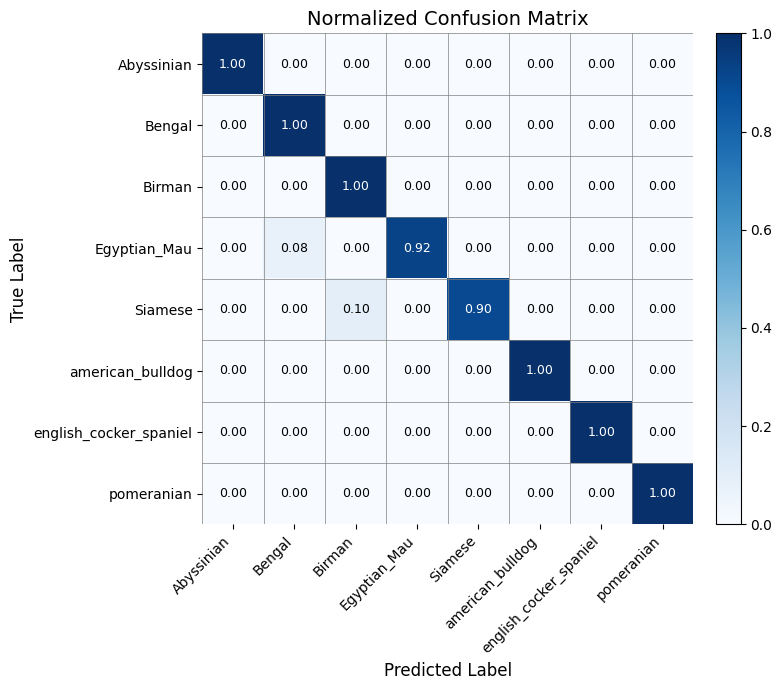

Saved: custom_confusion_matrix.png


In [10]:
import matplotlib.pyplot as plt
import numpy as np

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
cm_norm = np.nan_to_num(cm_norm)

fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(cm_norm, cmap="Blues")

# Set ticks
ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)
ax.set_title("Normalized Confusion Matrix", fontsize=14)

# Write values inside the cells
threshold = cm_norm.max() / 2
for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        ax.text(
            j, i,
            f"{cm_norm[i, j]:.2f}",
            ha="center",
            va="center",
            color="white" if cm_norm[i, j] > threshold else "black",
            fontsize=9
        )

# Styling
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.spines[:].set_visible(False)
ax.set_xticks(np.arange(cm_norm.shape[1]+1)-.5, minor=True)
ax.set_yticks(np.arange(cm_norm.shape[0]+1)-.5, minor=True)
ax.grid(which="minor", color="gray", linestyle='-', linewidth=0.5)
ax.tick_params(which="minor", bottom=False, left=False)

plt.tight_layout()
plt.savefig("custom_confusion_matrix.png", dpi=300)
plt.show()

print("Saved: custom_confusion_matrix.png")

In [11]:
import numpy as np

cm2 = cm.copy().astype(int)
np.fill_diagonal(cm2, 0)

i, j = np.unravel_index(np.argmax(cm2), cm2.shape)
print("Most confused pair:", class_names[i], "->", class_names[j], "count =", cm2[i, j])

Most confused pair: Egyptian_Mau -> Bengal count = 1


In [13]:
import os
from pathlib import Path
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import numpy as np

# ====== Confirm/set these two (used to build gcs_uri; keep consistent with AutoML later) ======
BUCKET = os.environ.get("BUCKET", "435-pets-bucket")
PREFIX = os.environ.get("PREFIX", "pets_subset")

data_dir = "data/images"
weights_path = "efficientnetb0_pets8_headonly.pth"  # The weights file you saved during training

assert os.path.isdir(data_dir), "Cannot find data/images"
assert os.path.exists(weights_path), f"Cannot find weights file {weights_path}"

device = "cpu"

eval_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

# ImageFolder: samples = [(path, class_index), ...]; order is sorted by filename, stable and reproducible
ds = datasets.ImageFolder(root=data_dir, transform=eval_tfms)
class_names = ds.classes
num_classes = len(class_names)

# ====== Rebuild the same 80/10/10 split used in training (same seed + same order) ======
seed = 42
n = len(ds)
n_train = int(0.8 * n)
n_val = int(0.1 * n)
n_test = n - n_train - n_val

g = torch.Generator().manual_seed(seed)
perm = torch.randperm(n, generator=g).tolist()
split = [""] * n
for idx in perm[:n_train]: split[idx] = "train"
for idx in perm[n_train:n_train+n_val]: split[idx] = "val"
for idx in perm[n_train+n_val:]: split[idx] = "test"

# ====== Load model ======
model = models.efficientnet_b0(weights=None)
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, num_classes)
model.load_state_dict(torch.load(weights_path, map_location=device))
model.to(device)
model.eval()

loader = DataLoader(ds, batch_size=32, shuffle=False, num_workers=2)

rows = []
softmax = nn.Softmax(dim=1)

# Get original paths and ground-truth labels (aligned with loader output because shuffle=False)
all_paths = [p for (p, y) in ds.samples]
all_true_idx = [y for (p, y) in ds.samples]

ptr = 0
with torch.no_grad():
    for xb, yb in loader:
        xb = xb.to(device)
        logits = model(xb)
        probs = softmax(logits).cpu().numpy()
        top3 = np.argsort(-probs, axis=1)[:, :3]

        bs = xb.shape[0]
        for i in range(bs):
            path = all_paths[ptr]
            true_idx = all_true_idx[ptr]
            ptr += 1

            # Build gcs_uri (in your GCS: pets_subset/images/<label>/<file>)
            label_folder = Path(path).parent.name
            fname = Path(path).name
            rel_path = f"images/{label_folder}/{fname}"
            gcs_uri = f"gs://{BUCKET}/{PREFIX}/{rel_path}"

            t1, t2, t3 = top3[i]
            rows.append({
                "local_path": path,
                "gcs_uri": gcs_uri,
                "true_label": class_names[true_idx],
                "split": split[ds.samples.index((path, true_idx))] if (path, true_idx) in ds.samples else "",
                "pred1": class_names[t1], "conf1": float(probs[i, t1]),
                "pred2": class_names[t2], "conf2": float(probs[i, t2]),
                "pred3": class_names[t3], "conf3": float(probs[i, t3]),
                "correct": bool(t1 == true_idx),
            })

df = pd.DataFrame(rows)

# Fix split (using index lookup above can be slow and may repeat; mapping by row number is most robust)
df["split"] = [split[i] for i in range(n)]

df.to_csv("custom_predictions_top3.csv", index=False)
print("Saved custom_predictions_top3.csv, shape =", df.shape)
print(df.head())
print("Test accuracy (from CSV):", df[df["split"]=="test"]["correct"].mean())

Saved custom_predictions_top3.csv, shape = (640, 11)
                          local_path  \
0  data/images/Abyssinian/000006.jpg   
1  data/images/Abyssinian/000012.jpg   
2  data/images/Abyssinian/000018.jpg   
3  data/images/Abyssinian/000038.jpg   
4  data/images/Abyssinian/000042.jpg   

                                             gcs_uri  true_label  split  \
0  gs://435-pets-bucket/pets_subset/images/Abyssi...  Abyssinian  train   
1  gs://435-pets-bucket/pets_subset/images/Abyssi...  Abyssinian   test   
2  gs://435-pets-bucket/pets_subset/images/Abyssi...  Abyssinian  train   
3  gs://435-pets-bucket/pets_subset/images/Abyssi...  Abyssinian  train   
4  gs://435-pets-bucket/pets_subset/images/Abyssi...  Abyssinian  train   

        pred1     conf1         pred2     conf2         pred3     conf3  \
0  Abyssinian  0.472755        Bengal  0.264755  Egyptian_Mau  0.194044   
1  Abyssinian  0.777118        Bengal  0.105342       Siamese  0.056398   
2  Abyssinian  0.743833    pom

In [14]:
err = df[(df["split"]=="test") & (~df["correct"])].copy()
err.to_csv("custom_misclassified_test.csv", index=False)
print("Misclassified test samples:", len(err))

pair = df[(df["split"]=="test") & (df["true_label"]=="Egyptian_Mau") & (df["pred1"]=="Bengal")]
pair.to_csv("pair_Egyptian_Mau_to_Bengal.csv", index=False)
print("Egyptian_Mau -> Bengal in test:", len(pair))
pair[["gcs_uri","true_label","pred1","conf1","pred2","conf2"]].head()

Misclassified test samples: 2
Egyptian_Mau -> Bengal in test: 1


,gcs_uri,true_label,pred1,conf1,pred2,conf2
256,gs://435-pets-bucket/pets_subset/images/Egypti...,Egyptian_Mau,Bengal,0.435684,Egyptian_Mau,0.358676


# Appendix

## script——AutoML batch prediction parsing script

In [ ]:
#!/usr/bin/env python3
"""
Parse AutoML batch prediction JSONL outputs, join with ground-truth labels,
export a top-3 predictions CSV, and compute basic metrics + confusion matrix.

Defaults match the original snippet:
  - Ground truth CSV: vertex_import.csv
  - Batch outputs directory: automl_batch_out/
  - Outputs:
      automl_predictions_top3.csv
      automl_confusion_matrix_counts.csv

Example:
  python evaluate_automl_batch_outputs.py

Optional arguments:
  python evaluate_automl_batch_outputs.py \
    --gt-csv vertex_import.csv \
    --out-dir automl_batch_out \
    --preds-csv automl_predictions_top3.csv \
    --cm-csv automl_confusion_matrix_counts.csv
"""

from __future__ import annotations

import argparse
import json
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Tuple

import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix


def _as_list(x: Any) -> List[Any]:
    if x is None:
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, dict):
        return list(x.values())
    return [x]


def extract_uri(rec: Dict[str, Any]) -> Optional[str]:
    """Try common fields used to store the instance URI."""
    inst = rec.get("instance") or {}
    if isinstance(inst, list) and inst:
        inst = inst[0]
    if not isinstance(inst, dict):
        return None
    return inst.get("content") or inst.get("gcsUri") or inst.get("uri") or inst.get("gcs_uri")


def extract_topk(rec: Dict[str, Any], k: int = 3) -> List[Tuple[Optional[str], Optional[float]]]:
    """Extract top-k (name, confidence) pairs from a prediction record."""
    pred = rec.get("prediction")
    if pred is None:
        pred = rec.get("predictions")
    if pred is None:
        return []

    # Sometimes predictions is a list of dicts
    if isinstance(pred, list):
        pred = pred[0] if pred else {}
    if not isinstance(pred, dict):
        return []

    names = pred.get("displayNames") or pred.get("display_names") or pred.get("classes") or []
    confs = pred.get("confidences") or pred.get("confidence") or pred.get("scores") or []

    names_list = _as_list(names)
    confs_list = _as_list(confs)

    # If we have confidences, zip names+confs; otherwise keep names with None conf.
    pairs: List[Tuple[Optional[str], Optional[float]]] = []
    if names_list and confs_list:
        for n, c in zip(names_list, confs_list):
            try:
                c_f = float(c) if c is not None else None
            except (TypeError, ValueError):
                c_f = None
            pairs.append((str(n) if n is not None else None, c_f))
    elif names_list:
        pairs = [(str(n) if n is not None else None, None) for n in names_list]

    return pairs[:k]


def load_ground_truth(gt_csv: Path) -> Dict[str, str]:
    """Read ground truth mapping from a 2-column CSV with no header."""
    gt = pd.read_csv(gt_csv, header=None, names=["gcs_uri", "true_label"])
    return dict(zip(gt["gcs_uri"], gt["true_label"]))


def iter_jsonl_files(out_dir: Path) -> Iterable[Path]:
    return out_dir.rglob("*.jsonl")


def main() -> None:
    parser = argparse.ArgumentParser(description="Evaluate AutoML batch JSONL outputs.")
    parser.add_argument("--gt-csv", default="vertex_import.csv", help="Ground truth CSV (default: vertex_import.csv)")
    parser.add_argument("--out-dir", default="automl_batch_out", help="Directory containing JSONL outputs")
    parser.add_argument("--preds-csv", default="automl_predictions_top3.csv", help="Output CSV for top-3 predictions")
    parser.add_argument("--cm-csv", default="automl_confusion_matrix_counts.csv", help="Output CSV for confusion matrix counts")
    args = parser.parse_args()

    gt_csv = Path(args.gt_csv)
    out_dir = Path(args.out_dir)
    preds_csv = Path(args.preds_csv)
    cm_csv = Path(args.cm_csv)

    # 1) Read ground truth (vertex_import.csv)
    gt_map = load_ground_truth(gt_csv)

    # 2) Find all batch output JSONL files
    jsonl_files = list(iter_jsonl_files(out_dir))
    assert jsonl_files, f"No JSONL output files found under: {out_dir}"

    rows: List[Dict[str, Any]] = []

    for fp in jsonl_files:
        with fp.open("r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                try:
                    rec = json.loads(line)
                except json.JSONDecodeError:
                    continue

                uri = extract_uri(rec)
                if not uri:
                    continue

                true_label = gt_map.get(uri)

                top = extract_topk(rec, k=3)

                row = {
                    "gcs_uri": uri,
                    "true_label": true_label,
                    "pred1": top[0][0] if len(top) > 0 else None,
                    "conf1": top[0][1] if len(top) > 0 else None,
                    "pred2": top[1][0] if len(top) > 1 else None,
                    "conf2": top[1][1] if len(top) > 1 else None,
                    "pred3": top[2][0] if len(top) > 2 else None,
                    "conf3": top[2][1] if len(top) > 2 else None,
                }
                rows.append(row)

    df = pd.DataFrame(rows).drop_duplicates(subset=["gcs_uri"])
    df["correct"] = df["pred1"] == df["true_label"]
    df.to_csv(preds_csv, index=False)

    # 3) Metrics (only rows that have both ground truth and a top-1 prediction)
    df_eval = df.dropna(subset=["true_label", "pred1"])
    y_true = df_eval["true_label"].tolist()
    y_pred = df_eval["pred1"].tolist()

    acc = accuracy_score(y_true, y_pred) if y_true else 0.0
    macro_f1 = f1_score(y_true, y_pred, average="macro") if y_true else 0.0

    labels = sorted(set(y_true))
    cm = confusion_matrix(y_true, y_pred, labels=labels) if labels else []

    print("AutoML top-1 accuracy:", round(acc, 4))
    print("AutoML macro-F1     :", round(macro_f1, 4))

    if labels:
        pd.DataFrame(cm, index=labels, columns=labels).to_csv(cm_csv)
        print(f"Saved: {preds_csv} and {cm_csv}")
    else:
        print(f"Saved: {preds_csv} (no labels found to compute confusion matrix)")


if __name__ == "__main__":
    main()


## Dataset construction script (sampling 8 classes, 80 images/class)

In [ ]:
#!/usr/bin/env python3
"""
Create a small Oxford Pets subset from Hugging Face Datasets, save images to disk,
and write a CSV manifest (relative_path,label).

Example:
  python make_pets_subset.py

Output:
  pets_subset/
    images/<label>/*.jpg
    manifest.csv
"""

from datasets import load_dataset
from pathlib import Path
import random
import re
import pandas as pd
from tqdm import tqdm


def norm(s: str) -> str:
    """Normalize labels for robust matching (case/spacing/punctuation-insensitive)."""
    return re.sub(r"[^a-z0-9]+", "", s.lower())


def main() -> None:
    random.seed(42)

    ds = load_dataset("enterprise-explorers/oxford-pets")["train"]

    # In this dataset, `label` is a string (e.g., "Birman", "wheaten terrier").
    # Build a normalized lookup to match names robustly.
    all_labels = sorted(set(ds["label"]))
    norm_to_label = {norm(l): l for l in all_labels}

    wanted = [
        "Abyssinian",
        "Bengal",
        "Birman",
        "Egyptian_Mau",
        "Siamese",
        "american_bulldog",
        "english_cocker_spaniel",
        "pomeranian",
    ]

    selected_labels = []
    for w in wanted:
        k = norm(w)
        if k not in norm_to_label:
            print("Not found:", w)
            print("You can choose from these labels (first 30):", all_labels[:30])
            raise SystemExit(1)
        selected_labels.append(norm_to_label[k])

    per_class = 80  # samples per class (small amount is enough to prove concept)

    # Collect samples per class
    by_label = {l: [] for l in selected_labels}
    for ex in ds:
        if ex["label"] in by_label:
            by_label[ex["label"]].append(ex)

    # Sample
    sampled = []
    for lab, items in by_label.items():
        random.shuffle(items)
        sampled.extend(items[:per_class])
    random.shuffle(sampled)

    # Save images + manifest
    out_root = Path("pets_subset")
    img_root = out_root / "images"
    img_root.mkdir(parents=True, exist_ok=True)

    rows = []
    for i, ex in enumerate(tqdm(sampled, desc="Saving images")):
        label = ex["label"]
        safe_label = label.replace(" ", "_")
        (img_root / safe_label).mkdir(parents=True, exist_ok=True)

        fname = f"{i:06d}.jpg"
        rel_path = f"images/{safe_label}/{fname}"
        local_path = out_root / rel_path

        ex["image"].convert("RGB").save(local_path, quality=95)
        rows.append([rel_path, safe_label])

    pd.DataFrame(rows, columns=["relative_path", "label"]).to_csv(
        out_root / "manifest.csv", index=False
    )

    print("✅ Done")
    print("Saved folder:", out_root.resolve())
    print("Manifest:", (out_root / "manifest.csv").resolve())
    print("Labels used:", sorted(set(r[1] for r in rows)))


if __name__ == "__main__":
    main()
